In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as img
import os
import cv2

In [24]:
os.listdir('/kaggle/input/sports-image-classification/dataset')

['sample_submission.csv', 'train.csv', 'test.csv', 'test', 'train']

In [25]:
img.imread('/kaggle/input/sports-image-classification/dataset/train/00133e413b.jpg').shape

(544, 860, 3)

In [26]:
df_train = pd.read_csv('/kaggle/input/sports-image-classification/dataset/train.csv')

In [27]:
df_train.head()

,image_ID,label
0,7c225f7b61.jpg,Badminton
1,b31.jpg,Badminton
2,acb146546c.jpg,Badminton
3,0e62f4d8f2.jpg,Badminton
4,cfd2c28c74.jpg,Cricket


In [28]:
data = {
    'Cricket':0,
    'Wrestling':1,
    'Tennis':2,
    'Badminton':3,
    'Soccer':4,
    'Swimming':5,
    'Karate':6
}

In [29]:
dict_ = {}
for index,row in df_train.iterrows():
    image_name = row[0]
    label_name = row[1]
    dict_[image_name] = data[label_name]

/tmp/ipykernel_55/395699360.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  image_name = row[0]
/tmp/ipykernel_55/395699360.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label_name = row[1]


In [30]:
X_train = []
y_train = []
for i in os.listdir('/kaggle/input/sports-image-classification/dataset/train')[:3000]:
    try:
        image = cv2.imread(f'/kaggle/input/sports-image-classification/dataset/train/{i}')
        image = cv2.resize(image, (224,224))
        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = preprocess_input(image)
        X_train.append(image)
        y_train.append(dict_[i])
    except:
        print(i)
X_train = np.array(X_train, dtype='float32')
y_train = np.array(y_train, dtype='float32')

In [31]:
X_train.shape, y_train.shape

((3000, 224, 224, 3), (3000,))

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Flatten, GlobalAveragePooling2D, Dense, Dropout
from keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2

In [35]:
from tensorflow.keras import layers

In [36]:
from keras.utils import to_categorical

In [37]:
y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

In [38]:
y_train[0]

array([0., 0., 1., 0., 0., 0., 0.])

In [39]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

In [46]:
base_model.trainable = True
for i in base_model.layers:
    if isinstance(i, layers.BatchNormalization):
        i.trainable = False

In [47]:
model = Sequential([
    
    base_model,
    GlobalAveragePooling2D(),
    
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(7, activation='softmax')
])

In [48]:
model.compile(optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

In [49]:
model.fit(X_train,y_train, validation_split=0.15, epochs=15, batch_size=32)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.1888 - loss: 2.0231 - val_accuracy: 0.3694 - val_loss: 1.7802
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.3074 - loss: 1.7485 - val_accuracy: 0.5583 - val_loss: 1.5038
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.4101 - loss: 1.5342 - val_accuracy: 0.6361 - val_loss: 1.2037
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.5386 - loss: 1.2720 - val_accuracy: 0.7000 - val_loss: 0.9694
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.6140 - loss: 1.0750 - val_accuracy: 0.7472 - val_loss: 0.8188
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.6705 - loss: 0.9534 - val_accuracy: 0.7944 - val_loss: 0.6788
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.7048 - loss: 0.8507 - val_accuracy: 0.8000 - val_loss: 0.6112
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.7659 - loss: 0.7348 - val_accuracy: 0.8167 - val_los

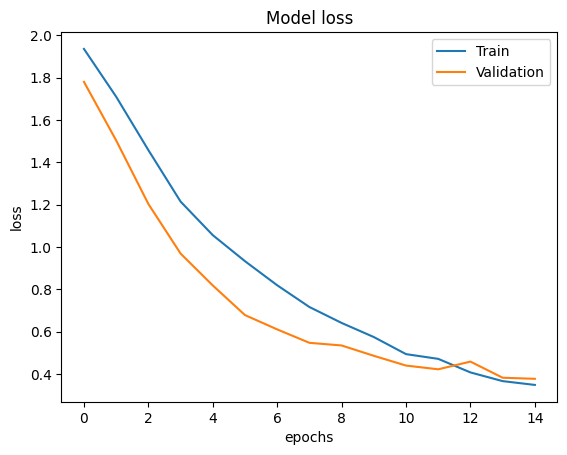

In [54]:
plt.plot(model.history.history['loss'], label='Train')
plt.plot(model.history.history['val_loss'], label='Validation')
plt.title('Model loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [51]:
model.evaluate(X_test,y_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 484ms/step - accuracy: 0.8655 - loss: 0.3877


[0.41177690029144287, 0.8616666793823242]